# HCD-302 Creating Explainable AI — Lab 1
## A Leak-Free, Nameable Pipeline

*การสร้าง scikit-learn Pipeline ที่ไม่มี data leakage และรักษาชื่อ feature ไว้ได้ตลอดสาย*

| | |
|---|---|
| **รายวิชา** | HCD-302 Creating Explainable AI |
| **สัปดาห์** | 2 · Data Transforms and Feature Engineering |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ |
| **เวลาทำแลป** | ในคาบประมาณ 50 นาที (พฤหัสบดี 15.30–17.20 น. ห้อง COC-404) |
| **กำหนดส่ง** | วันพฤหัสบดีที่ทำแลป ก่อนเวลา 18.00 น. ผ่าน LMS (lms.psu.ac.th) |
| **สิ่งที่ส่ง** | ไฟล์ `HCD302_Lab1_<รหัสนักศึกษา>.ipynb` ที่ **รันผลลัพธ์ไว้แล้ว** — ไฟล์ที่ไม่มีผลลัพธ์จะไม่ได้รับการตรวจ |
| **คะแนน** | 100 คะแนน คิดเป็นส่วนหนึ่งของคะแนน Lab (15% ของรายวิชา) · ทำเป็นรายบุคคล |

### 1. วัตถุประสงค์
เมื่อทำแลปนี้เสร็จ นักศึกษาจะสามารถ
1. สำรวจชุดข้อมูลสินเชื่อ ระบุชนิดคอลัมน์ สัดส่วนค่าว่าง และสัดส่วนคลาสของ target ได้
2. สร้าง `ColumnTransformer` ที่แยกสายตัวเลขและสายหมวดหมู่ แล้วรวมกับโมเดลเป็น `Pipeline` ออบเจกต์เดียว
3. เปรียบเทียบ StandardScaler, RobustScaler และการไม่ scale ภายใต้ 5-fold cross-validation ที่ไม่มี data leakage
4. ดึงชื่อ feature กลับมาด้วย `get_feature_names_out` และอ่านค่า coefficient แบบมาตรฐานได้อย่างถูกต้องพร้อมระบุหน่วย
5. อธิบายได้ว่าการ fit transformer บนข้อมูลทั้งหมดก่อนแบ่ง train/test ทำให้ผลการประเมินและคำอธิบายหลอกเราอย่างไร

### 2. ไฟล์และสภาพแวดล้อม
| ไฟล์ | คำอธิบาย |
|---|---|
| ชุดข้อมูล `credit_applications` | ใบสมัครสินเชื่อ 2,400 รายการ (ข้อมูลสังเคราะห์เพื่อการเรียนการสอน ไม่ใช่ข้อมูลลูกค้าจริง) — **ไม่ต้องดาวน์โหลดหรืออัปโหลดไฟล์ใด ๆ** เซลล์ 0.1 สร้างข้อมูลจากโค้ดที่ฝังไว้ด้วย seed คงที่ ทุกเครื่องได้ข้อมูลชุดเดียวกัน (ห้ามแก้ seed) |
| โน้ตบุ๊กนี้ | มีโครงสร้างงานทั้ง 5 งาน เซลล์ที่มี `# TODO` คือส่วนที่ต้องเขียนเอง เซลล์อื่นให้รันตามลำดับ |

สภาพแวดล้อม: Python ≥ 3.10, scikit-learn ≥ 1.2, pandas, matplotlib (`pip install scikit-learn pandas matplotlib`) ใช้ Jupyter Notebook, JupyterLab, VS Code หรือ Google Colab ก็ได้ ใช้ Colab ได้โดยไม่ต้องอัปโหลดไฟล์ใด ๆ

### 3. ชุดข้อมูล `credit_applications`
| คอลัมน์ | ชนิด | ความหมาย |
|---|---|---|
| `applicant_id` | int | รหัสผู้สมัคร — **ห้ามใช้เป็น feature** |
| `age` | numeric | อายุ (ปี) |
| `monthly_income` | numeric | รายได้ต่อเดือน (บาท) — มีค่าว่างประมาณ 10% |
| `loan_amount` | numeric | วงเงินสินเชื่อที่ขอ (บาท) |
| `debt_to_income_ratio` | numeric | ภาระหนี้ต่อเดือน ÷ รายได้ต่อเดือน — มีค่าว่าง |
| `n_late_payments` | numeric | จำนวนครั้งที่ชำระล่าช้าใน 12 เดือนที่ผ่านมา |
| `years_at_job` | numeric | อายุงานในที่ทำงานปัจจุบัน (ปี) — มีค่าว่าง |
| `dependents` | numeric | จำนวนผู้อยู่ในอุปการะ |
| `employment_type` | categorical | salaried / self_employed / government / student / freelance — มีค่าว่าง |
| `province` | categorical | จังหวัดที่พักอาศัย 15 จังหวัด |
| `default` | **target** | 1 = ผิดนัดชำระภายใน 12 เดือน, 0 = ไม่ผิดนัด (สัดส่วนผู้ผิดนัดประมาณ 22.6% ของทั้งหมด — คลาสไม่สมดุล) |

### 4. กติกา
- ห้าม fit transformer ใด ๆ (imputer, scaler, encoder) บนข้อมูลทั้งหมดก่อนแบ่ง train/test — ทุกขั้นตอนต้องอยู่ใน `Pipeline` และ Pipeline เป็นสิ่งเดียวที่ถูก fit
- ห้ามลบแถวที่มีค่าว่าง ให้ใช้ `SimpleImputer` และเก็บสัญญาณการไม่กรอกข้อมูลด้วย `add_indicator=True`
- ห้ามใส่ `applicant_id` และ `default` ไว้ในรายการ feature
- ใช้ `random_state=42` ทุกที่ที่มีการสุ่ม เพื่อให้ผลตรวจซ้ำได้

### 5. ภาพรวมงานทั้ง 5 งาน
| งาน | คะแนน | สิ่งที่ต้องทำ | สิ่งที่ส่ง |
|---|---|---|---|
| 1. Explore | 10 | ชนิดคอลัมน์ ค่าว่าง สัดส่วนคลาส และอัตราผิดนัดของกลุ่มที่ไม่กรอกรายได้ | ส่วน EDA สั้น ๆ พร้อมข้อสังเกต |
| 2. Build | 20 | แบ่งข้อมูลก่อน แล้วสร้าง `make_pipeline()` ตามโครงสร้างที่กำหนด | Pipeline ที่ fit ได้และผ่านเซลล์ทดสอบ 2.3 |
| 3. Compare | 20 | StandardScaler / RobustScaler / ไม่ scale × LogisticRegression / KNN ภายใต้ 5-fold CV | ตาราง mean ± std 6 ช่อง + คำอธิบาย |
| 4. Name | 30 | `get_feature_names_out` → จัดอันดับ 10 coefficient → กราฟ → คำอ่าน 3 บรรทัด | ตาราง + กราฟ + คำอ่านที่ระบุหน่วยถูกต้อง |
| 5. Reflect | 20 | รันการทดลอง leakage แล้วเขียนหนึ่งย่อหน้า | ย่อหน้าที่แสดงความเข้าใจกลไกของ leakage |


## 0. Setup
รันเซลล์นี้ก่อน — ตรวจสอบเวอร์ชันของไลบรารี (ต้องการ scikit-learn ≥ 1.2)

In [18]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, classification_report

import warnings
from sklearn.exceptions import ConvergenceWarning
# หมายเหตุ: LogisticRegression บนข้อมูลที่ "ไม่ scale" อาจลู่เข้าไม่ทันใน 1000 รอบ — นั่นเองก็เป็นอาการหนึ่งของการไม่ scale (ดูงานที่ 3)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
pd.set_option("display.width", 120)
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.6.1 | pandas 2.2.3


## งานที่ 1 — Explore (10 คะแนน)
ใช้ DataFrame `df` จากเซลล์ 0.1 แล้วตอบคำถามต่อไปนี้ด้วยโค้ดและข้อสังเกตสั้น ๆ
1. ชนิดข้อมูลของแต่ละคอลัมน์ และคอลัมน์ไหนควรเป็น **numeric** / **categorical**
2. สัดส่วนค่าว่างของแต่ละคอลัมน์
3. สัดส่วนคลาสของ `default`
4. **คำถามสำคัญ:** อัตราการผิดนัดของกลุ่มที่ *ไม่กรอก* `monthly_income` ต่างจากกลุ่มที่กรอกหรือไม่ — ค่านี้บอกอะไรเราเกี่ยวกับการทิ้งแถวที่มีค่าว่าง?

In [19]:
# 0.1 — สร้างชุดข้อมูล credit_applications (deterministic: seed 302 → ทุกเครื่องได้ข้อมูลชุดเดียวกัน ไม่ต้องดาวน์โหลดหรืออัปโหลดไฟล์ใด ๆ)
def generate_credit_data(n=2400, seed=302):
    """สร้างชุดข้อมูลใบสมัครสินเชื่อแบบสังเคราะห์ (ห้ามแก้ค่า seed)"""
    rng = np.random.default_rng(302)
    n = 2400
    provinces = ["Phuket", "Phang Nga", "Krabi", "Surat Thani", "Nakhon Si Thammarat", "Songkhla", "Trang",
                 "Satun", "Phatthalung", "Chumphon", "Ranong", "Bangkok", "Chiang Mai", "Khon Kaen", "Chon Buri"]
    prov_p = np.array([0.22, 0.06, 0.08, 0.10, 0.09, 0.11, 0.06, 0.03, 0.03, 0.04, 0.02, 0.08, 0.03, 0.03, 0.02])
    prov_p /= prov_p.sum()
    emp_types = ["salaried", "self_employed", "government", "student", "freelance"]
    emp_p = [0.42, 0.25, 0.13, 0.08, 0.12]

    age = np.clip(rng.normal(36, 10, n), 20, 68).round()
    employment_type = rng.choice(emp_types, n, p=emp_p)
    province = rng.choice(provinces, n, p=prov_p)
    base_inc = {"salaried": 10.4, "self_employed": 10.5, "government": 10.35, "student": 9.3, "freelance": 10.1}
    income = np.exp(np.array([base_inc[e] for e in employment_type]) + 0.012 * (age - 36) + rng.normal(0, 0.45, n))
    income = income.round(-2)
    loan_amount = np.exp(np.log(income) + rng.normal(1.6, 0.6, n)).round(-3)
    monthly_debt = np.exp(np.log(income) + rng.normal(-1.1, 0.7, n))
    dti = np.clip(monthly_debt / income, 0.02, 2.5).round(3)
    n_late = rng.poisson(0.6 + 1.5 * (dti > 0.5), n)
    years_at_job = np.clip(rng.exponential(4, n) * (employment_type != "student"), 0, 30).round(1)
    dependents = rng.choice([0, 1, 2, 3, 4], n, p=[0.35, 0.28, 0.22, 0.10, 0.05])
    region_map = {"Phuket": "South", "Phang Nga": "South", "Krabi": "South", "Surat Thani": "South", "Nakhon Si Thammarat": "South",
                  "Songkhla": "South", "Trang": "South", "Satun": "South", "Phatthalung": "South", "Chumphon": "South", "Ranong": "South",
                  "Bangkok": "Central", "Chiang Mai": "North", "Khon Kaen": "Northeast", "Chon Buri": "East"}

    # latent risk -> default
    emp_risk = {"salaried": -0.3, "self_employed": 0.35, "government": -0.6, "student": 0.5, "freelance": 0.3}
    prov_risk = {p: rng.normal(0, 0.10) for p in provinces}
    logit = (-2.3 + 2.2 * (dti - 0.35) + 0.55 * n_late - 0.02 * (age - 36) - 0.35 * (np.log(income) - 10.4)
             + np.array([emp_risk[e] for e in employment_type]) + np.array([prov_risk[p] for p in province])
             - 0.05 * years_at_job + 0.12 * dependents + 0.25 * (np.log(loan_amount) - np.log(income) - 1.6))
    p_default = 1 / (1 + np.exp(-logit))
    default = (rng.uniform(size=n) < p_default).astype(int)

    # informative missingness: high-risk applicants more often leave income blank
    miss_income = rng.uniform(size=n) < (0.04 + 0.28 * default)
    income_obs = income.astype(float); income_obs[miss_income] = np.nan
    dti_obs = dti.copy(); dti_obs[rng.uniform(size=n) < 0.04] = np.nan
    years_obs = years_at_job.copy(); years_obs[rng.uniform(size=n) < 0.03] = np.nan
    emp_obs = employment_type.astype(object); emp_obs[rng.uniform(size=n) < 0.02] = np.nan

    df = pd.DataFrame({
        "applicant_id": np.arange(100001, 100001 + n),
        "age": age.astype(int),
        "monthly_income": income_obs,
        "loan_amount": loan_amount,
        "debt_to_income_ratio": dti_obs,
        "n_late_payments": n_late,
        "years_at_job": years_obs,
        "dependents": dependents,
        "employment_type": emp_obs,
        "province": province,
        "default": default,
    })
    df = df.sample(frac=1, random_state=1).reset_index(drop=True)
    return df

df = generate_credit_data()
print(f"generated {df.shape[0]} rows x {df.shape[1]} cols")
df.head()

generated 2400 rows x 11 cols


,applicant_id,age,monthly_income,loan_amount,debt_to_income_ratio,n_late_payments,years_at_job,dependents,employment_type,province,default
0,101349,35,76100.0,528000.0,0.067,2,1.4,0,government,Songkhla,0
1,100469,28,33400.0,224000.0,0.671,1,0.4,2,salaried,Chumphon,0
2,101464,31,31700.0,344000.0,0.480,0,7.7,3,self_employed,Chumphon,0
3,102268,35,28800.0,334000.0,0.081,0,17.9,2,salaried,Phuket,0
4,100944,43,36600.0,202000.0,0.199,1,16.5,1,self_employed,Khon Kaen,0


In [20]:
# TODO 1.1 — ชนิดข้อมูลและสถิติพื้นฐาน
df.info()
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   applicant_id          2400 non-null   int64  
 1   age                   2400 non-null   int64  
 2   monthly_income        2160 non-null   float64
 3   loan_amount           2400 non-null   float64
 4   debt_to_income_ratio  2299 non-null   float64
 5   n_late_payments       2400 non-null   int64  
 6   years_at_job          2332 non-null   float64
 7   dependents            2400 non-null   int64  
 8   employment_type       2355 non-null   object 
 9   province              2400 non-null   object 
 10  default               2400 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 206.4+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
applicant_id,2400.0,NaN,NaN,NaN,101200.5,692.964646,100001.0,100600.75,101200.5,101800.25,102400.0
age,2400.0,NaN,NaN,NaN,36.334167,9.520343,20.0,30.0,36.0,43.0,68.0
monthly_income,2160.0,NaN,NaN,NaN,34718.935185,19106.550358,3800.0,21700.0,30700.0,43625.0,144800.0
loan_amount,2400.0,NaN,NaN,NaN,204930.833333,188634.082878,8000.0,86000.0,150000.0,264000.0,2775000.0
debt_to_income_ratio,2299.0,NaN,NaN,NaN,0.434512,0.331764,0.032,0.2105,0.339,0.5635,2.5
n_late_payments,2400.0,NaN,NaN,NaN,1.025,1.223383,0.0,0.0,1.0,2.0,8.0
years_at_job,2332.0,NaN,NaN,NaN,3.668439,3.889909,0.0,0.9,2.4,5.1,24.6
dependents,2400.0,NaN,NaN,NaN,1.262917,1.198008,0.0,0.0,1.0,2.0,4.0
employment_type,2355,5,salaried,982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,2400,15,Phuket,515,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# TODO 1.2 — สัดส่วนค่าว่างต่อคอลัมน์ (เรียงจากมากไปน้อย)
df.isnull().mean().sort_values(ascending=False)


,0
monthly_income,0.100000
debt_to_income_ratio,0.042083
years_at_job,0.028333
employment_type,0.018750
applicant_id,0.000000
age,0.000000
loan_amount,0.000000
n_late_payments,0.000000
dependents,0.000000
province,0.000000


In [22]:
# TODO 1.3 — สัดส่วนคลาสของ default
df["default"].value_counts(normalize=True).sort_index()


,proportion
default,
0,0.77375
1,0.22625


In [23]:
# TODO 1.4 — อัตราผิดนัดของกลุ่มที่กรอก vs ไม่กรอก monthly_income
df.assign(monthly_income_missing=df["monthly_income"].isna()) \
  .groupby("monthly_income_missing")["default"].mean()


,default
monthly_income_missing,
False,0.174537
True,0.691667


**ข้อสังเกตงานที่ 1 (เขียน 2–3 บรรทัด):**

จากผลการทดลองพบว่าข้อมูลมีค่าว่างในบางคอลัมน์ จึงต้องจัดการข้อมูลก่อนนำไปสร้างโมเดล
นอกจากนี้คลาส `default` มีสัดส่วนไม่เท่ากัน จึงควรแบ่งข้อมูลแบบ Stratified เพื่อรักษาสัดส่วนของแต่ละคลาส


## งานที่ 2 — Build (20 คะแนน)
สร้าง pipeline ที่ **fit ได้โดยไม่ error** ตามโครงสร้างนี้

```
X_train ─▶ ColumnTransformer "prep"
              ├─ num : SimpleImputer(median, add_indicator=True) ─▶ StandardScaler
              └─ cat : SimpleImputer(most_frequent) ─▶ OneHotEncoder(handle_unknown="ignore")
        ─▶ LogisticRegression(max_iter=1000)  "clf"
```

ข้อกำหนด
- แบ่ง train/test 80/20 ด้วย `stratify=y` และ `random_state=42` **ก่อน** fit อะไรทั้งสิ้น
- ห้ามใส่ `applicant_id` และ `default` ใน feature
- ใช้ `add_indicator=True` ในสายตัวเลข เพื่อเก็บสัญญาณ "ไม่กรอกข้อมูล" ที่พบในงานที่ 1
- รายงาน ROC-AUC บน test set

In [24]:
# TODO 2.1 — กำหนดรายชื่อคอลัมน์และแบ่งข้อมูล
# ======== Edit Code Here =============
num_cols = ["age", "monthly_income", "loan_amount", "debt_to_income_ratio",
            "n_late_payments", "years_at_job", "dependents"]
cat_cols = ["employment_type", "province"]
# =====================================
X = df[num_cols + cat_cols]
y = df["default"]

# ======== Edit Code Here =============
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
# =====================================
print(X_train.shape, X_test.shape, y_train.mean().round(3), y_test.mean().round(3))


(1920, 9) (480, 9) 0.226 0.227


In [25]:
# TODO 2.2 — สร้าง ColumnTransformer และ Pipeline
def make_pipeline(scaler=StandardScaler(), model=None):
    """คืน Pipeline ที่มี prep + clf. ถ้า scaler เป็น None ให้ข้ามขั้น scale"""
    num_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    # ======== Edit Code Here =============
    # ถ้า scaler ไม่ใช่ None ให้ต่อ ("scale", scaler) เข้าไปใน num_steps
    if scaler is not None:
        num_steps.append(("scale", scaler))

    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    prep = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])
    # =====================================
    if model is None:
        model = LogisticRegression(max_iter=1000)
    return Pipeline([("prep", prep), ("clf", model)])

model = make_pipeline()
model.fit(X_train, y_train)
print("test ROC-AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4))
model


test ROC-AUC: 0.8503


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'monthly_income',
                                                   'loan_amount',
                                                   'debt_to_income_ratio',
                                                   'n_late_payments',
                                                   'years_at_job',
                                                   'dependents']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['employment_type',
                                                   'province'])])),
                ('clf', LogisticRegression(max_iter=1000))])

In [26]:
# 2.3 — ตรวจสอบว่า pipeline ทนต่อหมวดที่ไม่เคยเห็น (ห้ามแก้เซลล์นี้ ต้องรันผ่าน)
probe = X_test.head(3).copy()
probe.loc[probe.index[0], "province"] = "Mae Hong Son"   # จังหวัดที่ไม่มีใน training
probe.loc[probe.index[1], "monthly_income"] = np.nan
print(model.predict_proba(probe)[:, 1].round(3))
print("OK — pipeline handles unseen category and NaN at prediction time")

[0.01  0.973 0.024]
OK — pipeline handles unseen category and NaN at prediction time


## งานที่ 3 — Compare (20 คะแนน)
เปรียบเทียบ **StandardScaler / RobustScaler / ไม่ scale** ภายใต้ **5-fold stratified CV บน training set** (ห้ามแตะ test set ในขั้นนี้)

ทำสองรอบ: กับ `LogisticRegression` และกับ `KNeighborsClassifier(n_neighbors=15)`
รายงานเป็นตาราง **mean ± std ของ ROC-AUC** แล้วตอบว่า
- scaler มีผลกับโมเดลไหนมากกว่ากัน เพราะอะไร
- ทำไมการใช้ `cross_val_score` กับ **Pipeline ทั้งอัน** จึงไม่มี leakage ทั้งที่มี scaler อยู่ข้างใน

In [27]:
# TODO 3.1 — วนลูปเปรียบเทียบ scaler × model ด้วย cross_val_score(scoring="roc_auc")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scalers = {"StandardScaler": StandardScaler(), "RobustScaler": RobustScaler(), "no scaling": None}
models = {"LogisticRegression": lambda: LogisticRegression(max_iter=1000),
          "KNN(k=15)": lambda: KNeighborsClassifier(n_neighbors=15)}

rows = []
# ======== Edit Code Here =============
for scaler_name, scaler in scalers.items():
    for model_name, model_fn in models.items():
        pipe = make_pipeline(scaler=scaler, model=model_fn())
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
        rows.append({
            "model": model_name,
            "scaler": scaler_name,
            "mean_auc": scores.mean(),
            "std_auc": scores.std()
        })

# =====================================
results = pd.DataFrame(rows)
results["mean ± std"] = results.apply(lambda r: f"{r.mean_auc:.4f} ± {r.std_auc:.4f}", axis=1)
results.pivot(index="scaler", columns="model", values="mean ± std").loc[["no scaling", "StandardScaler", "RobustScaler"]]


model,KNN(k=15),LogisticRegression
scaler,,
no scaling,0.5640 ± 0.0296,0.8408 ± 0.0113
StandardScaler,0.8192 ± 0.0165,0.8393 ± 0.0103
RobustScaler,0.8079 ± 0.0265,0.8396 ± 0.0102


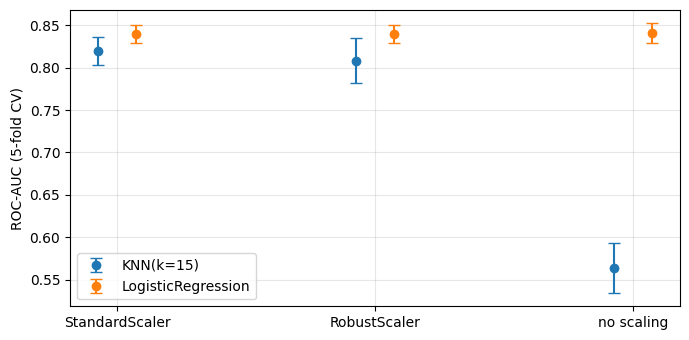

In [28]:
# 3.2 — กราฟเปรียบเทียบ (รันได้เลยเมื่อ results พร้อม)
fig, ax = plt.subplots(figsize=(7, 3.5))
for i, (mname, g) in enumerate(results.groupby("model")):
    ax.errorbar(np.arange(len(g)) + i * 0.15, g["mean_auc"], yerr=g["std_auc"], fmt="o", capsize=4, label=mname)
ax.set_xticks(np.arange(3) + 0.075); ax.set_xticklabels(results["scaler"].unique())
ax.set_ylabel("ROC-AUC (5-fold CV)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**คำตอบงานที่ 3 (เขียน 2–3 บรรทัด):**

Scaler มีผลกับ KNN มากกว่า เพราะ KNN ใช้ระยะห่างในการหาเพื่อนบ้าน จึงไวต่อสเกลของข้อมูล ส่วน Logistic Regression ได้รับผลน้อยกว่า
การใช้ `cross_val_score` กับ Pipeline ไม่เกิด leakage เพราะ scaler จะถูก fit เฉพาะข้อมูล training ของแต่ละ fold เท่านั้น


## งานที่ 4 — Name (30 คะแนน)
ใช้ pipeline ที่มี `StandardScaler` + `LogisticRegression` (fit บน training set แล้วในงานที่ 2)
1. ดึงชื่อ feature ของเมทริกซ์ที่ถูกแปลงด้วย `get_feature_names_out()` จาก step `prep` — สังเกต prefix `num__` / `cat__` และคอลัมน์ `missingindicator_*`
2. จับคู่ชื่อกับ `coef_` ของ `clf` แล้วจัดอันดับ **10 ตัวที่ |coefficient| ใหญ่ที่สุด**
3. วาดกราฟแท่งแนวนอน
4. เขียน **คำอ่านหนึ่งบรรทัดสำหรับสามอันดับแรก** ในภาษาที่เจ้าหน้าที่สินเชื่อเข้าใจ โดยระบุหน่วยให้ถูกต้อง (feature ตัวเลขถูก standardize แล้ว ⇒ coefficient คือการเปลี่ยนแปลงของ log-odds ต่อ **1 SD**; feature one-hot ⇒ เทียบกับกรณีที่คอลัมน์นั้นเป็น 0)

In [12]:
# TODO 4.1 — ชื่อ feature หลังการแปลง (ระวัง: เรียกจาก step "prep" ไม่ใช่จาก Pipeline ทั้งอัน)
# ======== Edit Code Here =============
names = model.named_steps["prep"].get_feature_names_out()
# =====================================
print(len(names))
print(names)


30
['num__age' 'num__monthly_income' 'num__loan_amount'
 'num__debt_to_income_ratio' 'num__n_late_payments' 'num__years_at_job'
 'num__dependents' 'num__missingindicator_monthly_income'
 'num__missingindicator_debt_to_income_ratio'
 'num__missingindicator_years_at_job' 'cat__employment_type_freelance'
 'cat__employment_type_government' 'cat__employment_type_salaried'
 'cat__employment_type_self_employed' 'cat__employment_type_student'
 'cat__province_Bangkok' 'cat__province_Chiang Mai'
 'cat__province_Chon Buri' 'cat__province_Chumphon'
 'cat__province_Khon Kaen' 'cat__province_Krabi'
 'cat__province_Nakhon Si Thammarat' 'cat__province_Phang Nga'
 'cat__province_Phatthalung' 'cat__province_Phuket' 'cat__province_Ranong'
 'cat__province_Satun' 'cat__province_Songkhla'
 'cat__province_Surat Thani' 'cat__province_Trang']


In [13]:
# TODO 4.2 — จับคู่ชื่อกับ coefficient แล้วเรียงตาม |coef| (10 อันดับแรก)
# ======== Edit Code Here =============
coefs = model.named_steps["clf"].coef_[0]
effects = pd.Series(coefs, index=names, name="coef").sort_values(
    key=np.abs, ascending=False
)
# =====================================
top10 = effects.head(10)
top10.to_frame().assign(odds_ratio=lambda d: np.exp(d["coef"])).round(3)


,coef,odds_ratio
num__debt_to_income_ratio,0.834,2.302
num__missingindicator_monthly_income,0.690,1.993
num__n_late_payments,0.591,1.806
cat__province_Ranong,-0.487,0.615
cat__employment_type_salaried,-0.374,0.688
cat__employment_type_freelance,0.348,1.416
num__monthly_income,-0.343,0.709
cat__province_Chon Buri,0.342,1.408
num__years_at_job,-0.292,0.747
cat__employment_type_government,-0.269,0.764


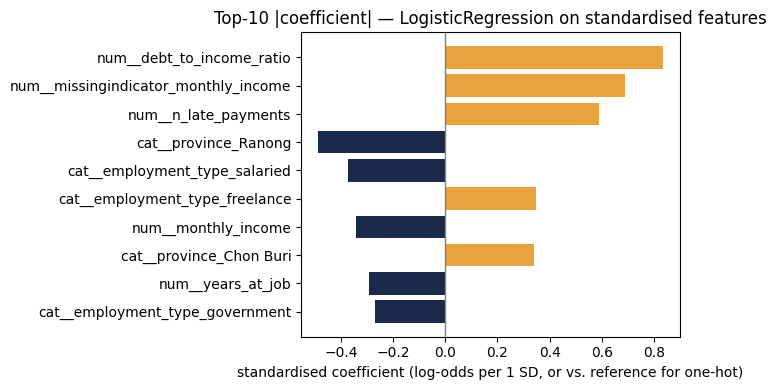

In [14]:
# 4.3 — กราฟ (รันได้เมื่อ top10 พร้อม)
top10 = effects.head(10)
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#E8A33D" if v > 0 else "#1B2A4A" for v in top10[::-1]]
ax.barh(top10.index[::-1], top10[::-1], color=colors)
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("standardised coefficient (log-odds per 1 SD, or vs. reference for one-hot)")
ax.set_title("Top-10 |coefficient| — LogisticRegression on standardised features")
plt.tight_layout(); plt.show()

In [15]:
# 4.4 — ตรวจสอบตัวเอง: ถ้าไม่ scale ตัวเลข การเรียงลำดับด้วย |coef| จะเปลี่ยนไปอย่างไร? (รันแล้วสังเกต)
raw = make_pipeline(scaler=None).fit(X_train, y_train)
raw_eff = pd.Series(raw.named_steps["clf"].coef_[0],
                    index=raw.named_steps["prep"].get_feature_names_out())
pd.DataFrame({"scaled_rank": effects.abs().rank(ascending=False).astype(int),
              "raw_rank": raw_eff.abs().rank(ascending=False).astype(int),
              "raw_coef": raw_eff.round(6)}).loc[top10.index]

,scaled_rank,raw_rank,raw_coef
num__debt_to_income_ratio,1,2,2.258982
num__missingindicator_monthly_income,2,1,2.298307
num__n_late_payments,3,3,0.465187
cat__province_Ranong,4,9,-0.187203
cat__employment_type_salaried,5,4,-0.403115
cat__employment_type_freelance,6,8,0.193136
num__monthly_income,7,29,-0.000024
cat__province_Chon Buri,8,18,0.080388
num__years_at_job,9,17,-0.085955
cat__employment_type_government,10,5,-0.376451


**คำอ่านสามอันดับแรก (หนึ่งบรรทัดต่อ feature ระบุหน่วยให้ชัด):**

1. debt_to_income_ratio — เพิ่มขึ้น 1 SD ทำให้โอกาสผิดนัดเพิ่มขึ้นมากที่สุด
2. monthly_income ที่เป็นค่าว่าง — จาก 0 เป็น 1 (ไม่กรอกรายได้) ทำให้โอกาสผิดนัดเพิ่มขึ้น
3. n_late_payments — เพิ่มขึ้น 1 SD หรือประมาณ 1.4 ครั้ง ทำให้โอกาสผิดนัดเพิ่มขึ้น



## งานที่ 5 — Reflect (20 คะแนน)
รันการทดลองด้านล่างซึ่ง **จงใจทำผิด** (fit scaler บนข้อมูลทั้งหมดก่อนแบ่ง) แล้วเปรียบเทียบกับวิธีที่ถูกต้อง

จากนั้นเขียน **หนึ่งย่อหน้า** ตอบว่า
- ผลลัพธ์ข้อใดในงานที่ 3–4 จะ "หลอก" เราถ้า scaler ถูก fit บนข้อมูลทั้งหมด และหลอกในทิศทางไหน
- ทำไมความต่างของตัวเลขจึงอาจ **เล็ก** ในชุดข้อมูลนี้ แต่ยังถือว่าเป็นความผิดพลาดร้ายแรง (คิดถึงกรณี target encoding, การ impute ด้วยค่าเฉลี่ย, หรือ feature selection)
- คำอธิบาย (coefficient / SHAP) ที่ได้จากโมเดลที่มี leakage อธิบาย "อะไร" กันแน่

In [16]:
# 5.1 — การทดลอง: WRONG vs RIGHT (รันแล้วสังเกต ไม่ต้องแก้)
num_only = num_cols
# WRONG: impute + scale บนข้อมูล *ทั้งหมด* ก่อนแบ่ง
leaky_prep = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                       ("scale", StandardScaler())])
X_all_leaky = leaky_prep.fit_transform(X[num_only])            # <-- test rows influence median / mean / std
Xtr_l, Xte_l, ytr, yte = train_test_split(X_all_leaky, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
leaky_clf = LogisticRegression(max_iter=1000).fit(Xtr_l, ytr)

# RIGHT: ทุกอย่างอยู่ใน Pipeline, fit บน train เท่านั้น
from sklearn.base import clone
right = Pipeline([("prep", clone(leaky_prep)), ("clf", LogisticRegression(max_iter=1000))])
right.fit(X_train[num_only], y_train)

print("WRONG  test AUC:", round(roc_auc_score(yte,    leaky_clf.predict_proba(Xte_l)[:, 1]), 4))
print("RIGHT  test AUC:", round(roc_auc_score(y_test, right.predict_proba(X_test[num_only])[:, 1]), 4))
print()
print("median used for monthly_income imputation — WRONG (all data):",
      leaky_prep.named_steps["impute"].statistics_[num_only.index("monthly_income")].round(1))
print("median used for monthly_income imputation — RIGHT (train only):",
      right.named_steps["prep"].named_steps["impute"].statistics_[num_only.index("monthly_income")].round(1))

WRONG  test AUC: 0.8587
RIGHT  test AUC: 0.8587

median used for monthly_income imputation — WRONG (all data): 30700.0
median used for monthly_income imputation — RIGHT (train only): 30700.0


In [17]:
# 5.2 — ขยายให้เห็นชัดขึ้น: leakage ผ่าน target encoding แบบผิด ๆ (รันแล้วสังเกต)
# แทน province ด้วยอัตราผิดนัดเฉลี่ยของจังหวัด คำนวณจาก "ข้อมูลทั้งหมด" (ผิด) เทียบกับคำนวณจาก train เท่านั้น (ถูก)
prov_rate_all   = df.groupby("province")["default"].mean()                 # WRONG: uses test labels
prov_rate_train = y_train.groupby(X_train["province"]).mean()              # RIGHT
def te(frame, rates): return frame["province"].map(rates).fillna(y_train.mean()).to_frame("province_te")

auc_wrong = roc_auc_score(y_test, LogisticRegression().fit(te(X_train, prov_rate_all), y_train)
                          .predict_proba(te(X_test, prov_rate_all))[:, 1])
auc_right = roc_auc_score(y_test, LogisticRegression().fit(te(X_train, prov_rate_train), y_train)
                          .predict_proba(te(X_test, prov_rate_train))[:, 1])
print(f"province target-encoding only — WRONG (rates from all data): AUC {auc_wrong:.4f}")
print(f"province target-encoding only — RIGHT (rates from train):    AUC {auc_right:.4f}")

province target-encoding only — WRONG (rates from all data): AUC 0.5279
province target-encoding only — RIGHT (rates from train):    AUC 0.4766


**คำตอบงานที่ 5 (หนึ่งย่อหน้า):**

ถ้า fit scaler บนข้อมูลทั้งหมดก่อนแบ่ง จะเกิด data leakage ทำให้ผล ROC-AUC ในงานที่ 3 ดูดีกว่าความเป็นจริง และ coefficient ในงานที่ 4 อาจไม่น่าเชื่อถือ แม้ชุดข้อมูลนี้ตัวเลขอาจต่างกันไม่มาก แต่ในกรณีอย่าง target encoding, imputation หรือ feature selection ผลอาจเปลี่ยนมากได้ ดังนั้น coefficient หรือ SHAP จากโมเดลที่มี leakage จะอธิบายโมเดลที่ได้รับข้อมูลจาก test set ทางอ้อม ไม่ใช่โมเดลที่ประเมินอย่างถูกต้อง


---
## เกณฑ์การให้คะแนน (Rubric — รวม 100)

| งาน | คะแนน | ดีมาก (เต็ม) | พอใช้ (ครึ่ง) | ต้องปรับปรุง (0–20%) |
|---|---|---|---|---|
| 1 Explore | 10 | ระบุชนิดคอลัมน์ถูกครบ แสดงค่าว่างและสัดส่วนคลาส ตอบข้อ 1.4 พร้อมนัยของการทิ้งแถว | แสดงสถิติครบแต่ข้อสังเกตตื้นหรือไม่ตอบข้อ 1.4 | รันไม่ผ่านหรือไม่มีข้อสังเกต |
| 2 Build | 20 | แบ่งข้อมูลก่อน fit, สองสายใน ColumnTransformer, `handle_unknown="ignore"`, `add_indicator=True`, เซลล์ 2.3 ผ่าน | Pipeline ทำงานได้แต่ขาดองค์ประกอบ 1–2 ข้อ | fit นอก Pipeline หรือ fit ก่อนแบ่งข้อมูล |
| 3 Compare | 20 | ตาราง 6 ช่องครบ mean ± std, อธิบายผลต่อ KNN vs LR ถูกต้อง, อธิบายกลไก clone-and-refit ในแต่ละ fold ได้ | ตารางครบแต่คำอธิบายไม่ถูกต้องหรือไม่ครบ | ตารางไม่ครบ หรือใช้ test set ในการเปรียบเทียบ |
| 4 Name | 30 | ชื่อ feature มี prefix ถูกต้อง, 10 อันดับพร้อมกราฟ, คำอ่าน 3 บรรทัดระบุหน่วย per 1 SD / vs reference ถูกต้อง, สังเกตผลจาก 4.4 ได้ | ได้ชื่อและอันดับ แต่คำอ่านไม่ระบุหน่วยหรืออ่านผิดทิศทาง | ใช้ x0…xN หรือจับคู่ชื่อกับ coefficient ผิด |
| 5 Reflect | 20 | อธิบายทิศทางของ bias, เหตุผลที่ผลต่างเล็กแต่ร้ายแรง (ยกกรณี target encoding / feature selection), และสิ่งที่คำอธิบายจากโมเดลรั่วอธิบายจริง ๆ | อธิบายได้บางประเด็น หรือกล่าวรวม ๆ ว่า "ผลดีเกินจริง" โดยไม่อธิบายกลไก | ไม่ตอบหรือตอบไม่ตรงคำถาม |

